In [ ]:


import cv2
import os
import random

def process_images(source_folder, destination_folder, num_images=50):
    """Reads images from a source folder, processes them, and saves them to a destination folder.

    Args:
        source_folder: Path to the folder containing the source images.
        destination_folder: Path to the folder where processed images will be saved.
        num_images: The number of images to process.
    """

    # Create the destination folder if it doesn't exist
    os.makedirs(destination_folder, exist_ok=True)

    image_files = [f for f in os.listdir(source_folder) if os.path.isfile(os.path.join(source_folder, f))]

    if len(image_files) < num_images:
      print(f"Warning: Only {len(image_files)} images found in the source folder. Processing all of them.")
      num_images = len(image_files)

    # Randomly select images
    selected_images = random.sample(image_files, num_images)

    for i, image_file in enumerate(selected_images):
        image_path = os.path.join(source_folder, image_file)

        try:
            # Read the image using OpenCV
            img = cv2.imread(image_path)

            if img is None:
                print(f"Error: Could not read image {image_path}")
                continue

            # Example processing: You can add your image processing code here
            # For instance, resize the image
            # img = cv2.resize(img, (256, 256))


            # Define the output path
            output_path = os.path.join(destination_folder, f"processed_{i}_{image_file}")

            # Write the image to the destination folder
            cv2.imwrite(output_path, img)
            print(f"Processed image {i+1}/{num_images}: {image_file}")

        except Exception as e:
            print(f"Error processing image {image_file}: {e}")

# Example usage
source_folder = "/content/drive/MyDrive/Brain Tumors" # Replace with the actual path
destination_folder = "/content/drive/MyDrive/ABCD OUTPUT" #Replace with the actual path

process_images(source_folder, destination_folder)


Processed image 1/50: Glioma15.jpg
Processed image 2/50: Meningioma13.jpg
Processed image 3/50: Glioma1.jpg
Processed image 4/50: Meningioma6.jpg
Processed image 5/50: Pituitary_tumor5.jpg
Processed image 6/50: Pituitary_tumor11.jpg
Processed image 7/50: Meningioma2.jpg
Processed image 8/50: Meningioma9.jpg
Processed image 9/50: No_tumor3.jpg
Processed image 10/50: No_tumor1.jpg
Processed image 11/50: Glioma2.jpg
Processed image 12/50: GLioma4.jpg
Processed image 13/50: Pituitary_tumor12.jpg
Processed image 14/50: Glioma10.jpg
Processed image 15/50: Meningioma7.jpg
Processed image 16/50: Glioma8.jpg
Processed image 17/50: Pituitary_tumor2.jpg
Processed image 18/50: No-tumor4.jpg
Processed image 19/50: Pituitary_tumor7.jpg
Processed image 20/50: No_tumor8.jpg
Processed image 21/50: Meningioma1.jpg
Processed image 22/50: No_tumor2.jpg
Processed image 23/50: Glioma6.jpg
Processed image 24/50: Meningioma8.jpg
Processed image 25/50: Pituitary_tumor6.jpg
Processed image 26/50: Meningioma11.j

In [ ]:


import cv2
import os
from google.colab.patches import cv2_imshow # Import the necessary function


def display_images_in_folder(folder_path):
    """Displays all images in a given folder using OpenCV.

    Args:
        folder_path: The path to the folder containing the images.
    """

    image_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        img = cv2.imread(image_path)

        if img is not None:
            cv2_imshow(img) # Use cv2_imshow instead of cv2.imshow
            cv2.waitKey(0)  # Wait for a key press to display the next image
            cv2.destroyAllWindows() # Close the current window
        else:
            print(f"Could not read image: {image_path}")

# Example usage:
folder_path = "/content/drive/MyDrive/Output_brainTumor"  # Replace with the actual path to your image folder
display_images_in_folder(folder_path)

In [ ]:

import cv2
import matplotlib.pyplot as plt
import os
import random

def process_images(input_folder, num_images=50):
    """Reads images, displays them and their histograms."""

    image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]

    if len(image_files) < num_images:
        print(f"Warning: Only {len(image_files)} images found. Processing all of them.")
        num_images = len(image_files)

    selected_images = random.sample(image_files, num_images)

    for image_file in selected_images:
        input_path = os.path.join(input_folder, image_file)
        try:
            img = cv2.imread(input_path)
            if img is None:
                print(f"Warning: Could not read image: {input_path}. Skipping")
                continue

            # Display the original image
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for Matplotlib
            plt.title("Original Image")

            # Calculate and display the histogram
            plt.subplot(1, 2, 2)
            color = ('b', 'g', 'r')
            for i, col in enumerate(color):
                histr = cv2.calcHist([img], [i], None, [256], [0, 256])
                plt.plot(histr, color=col)
                plt.xlim([0, 256])
            plt.title("Image Histogram")

            plt.show()

        except Exception as e:
            print(f"Error processing {image_file}: {e}")


# Example usage:
input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with your input folder path
process_images(input_folder)


In [ ]:

import cv2
import os
import random
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

def apply_filters(image):
    # Apply different smoothing filters
    kernel_size = 5  # Adjust kernel size as needed

    # Box Filter
    box_filtered = cv2.blur(image, (kernel_size, kernel_size))

    # Weighted Average Filter
    weighted_kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
    weighted_filtered = cv2.filter2D(image, -1, weighted_kernel)

    # Gaussian Filter
    gaussian_filtered = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

    # Median Filter
    median_filtered = cv2.medianBlur(image, kernel_size)

    # Max Filter
    max_filtered = cv2.dilate(image, np.ones((kernel_size, kernel_size), np.uint8))

    # Min Filter
    min_filtered = cv2.erode(image, np.ones((kernel_size, kernel_size), np.uint8))

    return box_filtered, weighted_filtered, gaussian_filtered, median_filtered, max_filtered, min_filtered


def process_images(input_folder, num_images=50):
    image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]

    if len(image_files) < num_images:
        print(f"Warning: Only {len(image_files)} images found. Processing all of them.")
        num_images = len(image_files)

    selected_images = random.sample(image_files, num_images)

    for image_file in selected_images:
        input_path = os.path.join(input_folder, image_file)
        try:
            img = cv2.imread(input_path)
            if img is None:
                print(f"Warning: Could not read image: {input_path}. Skipping")
                continue

            #Apply filters
            box, weighted, gaussian, median, max_f, min_f = apply_filters(img)

            # Display the original image and filtered images
            plt.figure(figsize=(20, 10))

            plt.subplot(2, 4, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("Original Image")

            plt.subplot(2, 4, 2)
            plt.imshow(cv2.cvtColor(box, cv2.COLOR_BGR2RGB))
            plt.title("Box Filter")

            plt.subplot(2, 4, 3)
            plt.imshow(cv2.cvtColor(weighted, cv2.COLOR_BGR2RGB))
            plt.title("Weighted Average Filter")

            plt.subplot(2, 4, 4)
            plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
            plt.title("Gaussian Filter")

            plt.subplot(2, 4, 5)
            plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
            plt.title("Median Filter")

            plt.subplot(2, 4, 6)
            plt.imshow(cv2.cvtColor(max_f, cv2.COLOR_BGR2RGB))
            plt.title("Max Filter")

            plt.subplot(2, 4, 7)
            plt.imshow(cv2.cvtColor(min_f, cv2.COLOR_BGR2RGB))
            plt.title("Min Filter")

            plt.show()


        except Exception as e:
            print(f"Error processing {image_file}: {e}")

# Example usage
input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with your input folder
process_images(input_folder, num_images=10) #process only 5 images


In [ ]:


import cv2
import os
import random
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

def apply_filters(image):
    # Apply different sharpening filters

    # Simple Laplacian
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    laplacian = np.uint8(np.absolute(laplacian))

    # Laplacian variants (using different kernels)
    laplacian_kernel_1 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
    laplacian_1 = cv2.filter2D(image, -1, laplacian_kernel_1)

    laplacian_kernel_2 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    laplacian_2 = cv2.filter2D(image, -1, laplacian_kernel_2)

    # Sobel filters
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
    sobelx = np.uint8(np.absolute(sobelx))
    sobely = np.uint8(np.absolute(sobely))
    sobel_combined = cv2.bitwise_or(sobelx, sobely)

    return laplacian, laplacian_1, laplacian_2, sobelx, sobely, sobel_combined


def process_images(input_folder, num_images=50):
    image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]

    if len(image_files) < num_images:
        print(f"Warning: Only {len(image_files)} images found. Processing all of them.")
        num_images = len(image_files)

    selected_images = random.sample(image_files, num_images)

    for image_file in selected_images:
        input_path = os.path.join(input_folder, image_file)
        try:
            img = cv2.imread(input_path)
            if img is None:
                print(f"Warning: Could not read image: {input_path}. Skipping")
                continue

            # Apply filters
            lap, lap1, lap2, sobx, soby, sob_combined = apply_filters(img)

            # Display the original image and filtered images
            plt.figure(figsize=(20, 10))

            plt.subplot(2, 4, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("Original Image")

            plt.subplot(2, 4, 2)
            plt.imshow(lap, cmap='gray')
            plt.title("Laplacian")

            plt.subplot(2, 4, 3)
            plt.imshow(lap1, cmap='gray')
            plt.title("Laplacian Variant 1")

            plt.subplot(2, 4, 4)
            plt.imshow(lap2, cmap='gray')
            plt.title("Laplacian Variant 2")

            plt.subplot(2, 4, 5)
            plt.imshow(sobx, cmap='gray')
            plt.title("Sobel X")

            plt.subplot(2, 4, 6)
            plt.imshow(soby, cmap='gray')
            plt.title("Sobel Y")

            plt.subplot(2, 4, 7)
            plt.imshow(sob_combined, cmap='gray')
            plt.title("Sobel Combined")

            plt.show()

        except Exception as e:
            print(f"Error processing {image_file}: {e}")

# Example usage
input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with your input folder
process_images(input_folder, num_images=5) # Process only 5 images


In [ ]:


import cv2
import os
import random
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

input_folder = "/content/drive/MyDrive/Brain Tumors"
num_images = 50



image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]
num_images = min(num_images, len(image_files))
selected_images = random.sample(image_files, num_images)


for image_file in selected_images:
    input_path = os.path.join(input_folder, image_file)
    img = cv2.imread(input_path)
    if img is None:
        print(f"Warning: Could not read image: {input_path}. Skipping")
        continue

    # Digital Negative
    negative = 255 - img

    # Thresholding (example: simple binary threshold)
    _, thresholded = cv2.threshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 127, 255, cv2.THRESH_BINARY)

    # Logarithmic Transformation
    c = 255 / np.log(1 + np.max(img))
    log_transformed = c * np.log(1 + img)
    log_transformed = np.array(log_transformed, dtype=np.uint8)


    # Power-Law Transformation (Gamma Correction)
    gamma = 2.2 # Adjust gamma value
    gamma_corrected = np.power(img / 255.0, gamma) * 255.0
    gamma_corrected = np.array(gamma_corrected, dtype=np.uint8)

    # Display and save
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")

    plt.subplot(1, 5, 2)
    plt.imshow(cv2.cvtColor(negative, cv2.COLOR_BGR2RGB))
    plt.title("Negative")

    plt.subplot(1, 5, 3)
    plt.imshow(thresholded, cmap='gray')
    plt.title("Thresholded")

    plt.subplot(1, 5, 4)
    plt.imshow(cv2.cvtColor(log_transformed, cv2.COLOR_BGR2RGB))
    plt.title("Log Transformed")

    plt.subplot(1, 5, 5)
    plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
    plt.title("Gamma Corrected")


    plt.show()



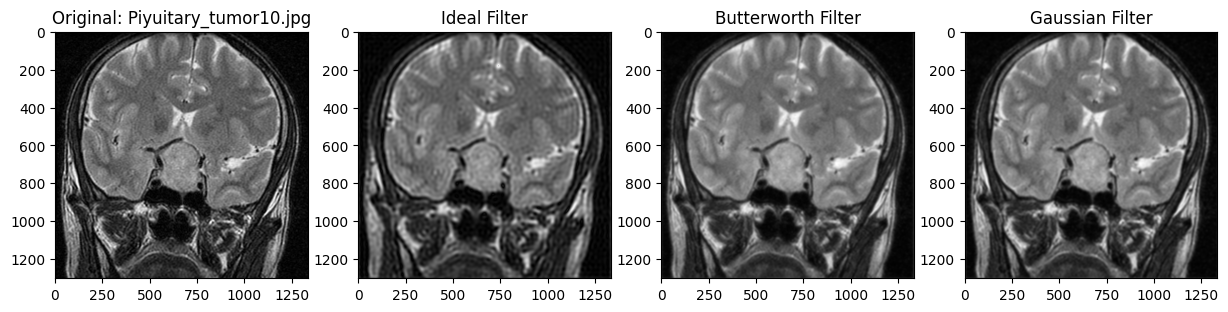

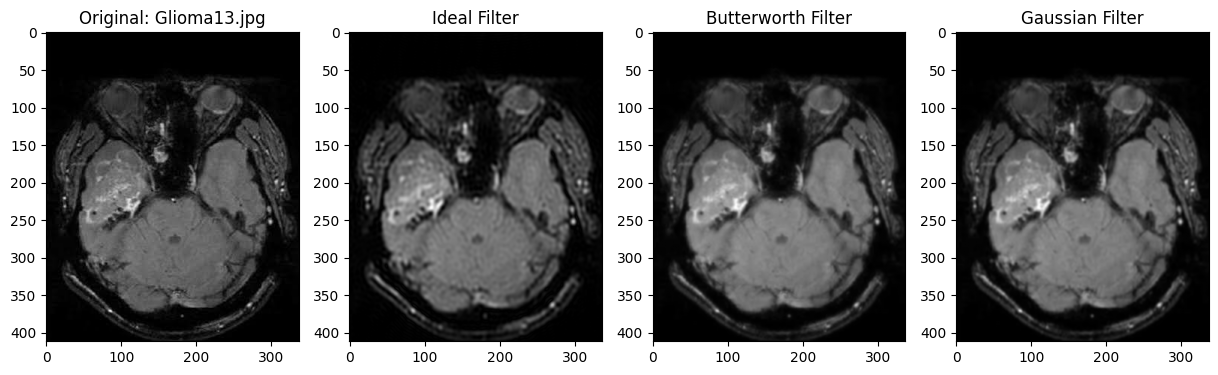

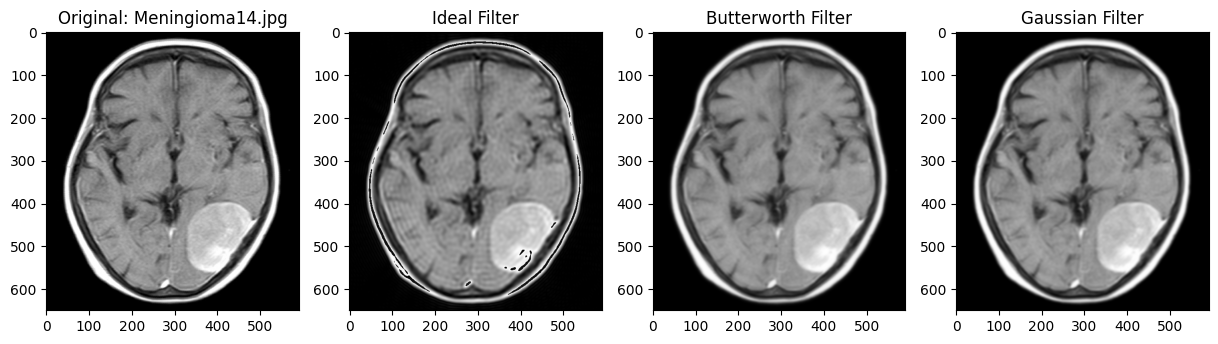

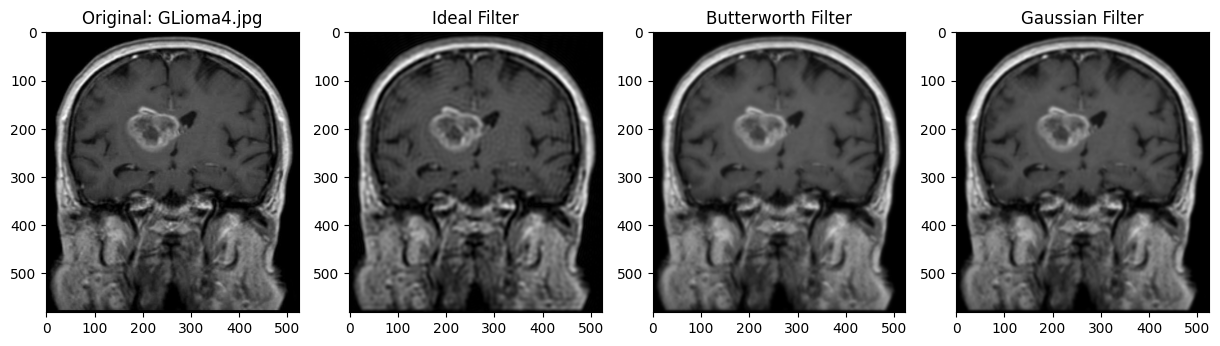

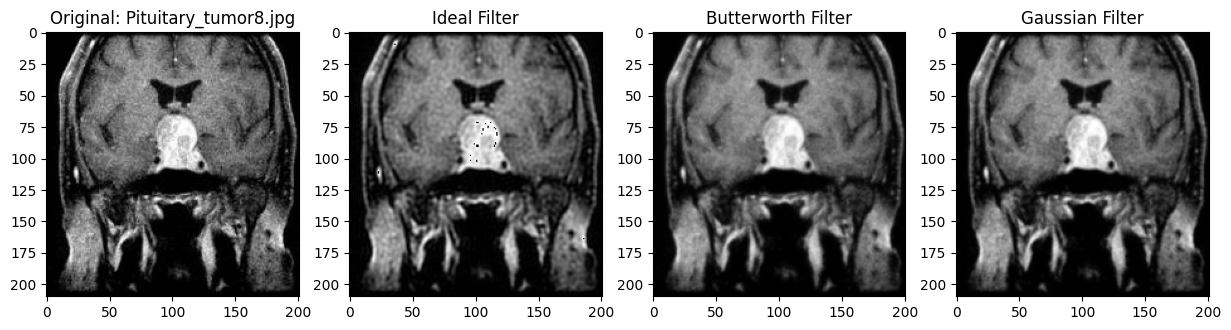

In [ ]:


def ideal_low_pass_filter(image, cutoff_frequency):
    rows, cols = image.shape[:2]
    center_row, center_col = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
            if distance <= cutoff_frequency:
                mask[i, j] = 1
    return mask

def butterworth_low_pass_filter(image, cutoff_frequency, order):
    rows, cols = image.shape[:2]
    center_row, center_col = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
            mask[i, j] = 1 / (1 + (distance / cutoff_frequency)**(2 * order))
    return mask

def gaussian_low_pass_filter(image, cutoff_frequency):
    rows, cols = image.shape[:2]
    center_row, center_col = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
            mask[i, j] = np.exp(-(distance**2) / (2 * (cutoff_frequency**2)))
    return mask

def process_image_frequency_domain(image, filter_type, cutoff_frequency, order=1):
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  f = np.fft.fft2(gray_image)
  fshift = np.fft.fftshift(f)
  magnitude_spectrum = 20 * np.log(np.abs(fshift))

  if filter_type == 'ideal':
    filter_mask = ideal_low_pass_filter(gray_image, cutoff_frequency)
  elif filter_type == 'butterworth':
      filter_mask = butterworth_low_pass_filter(gray_image, cutoff_frequency, order)
  elif filter_type == 'gaussian':
      filter_mask = gaussian_low_pass_filter(gray_image, cutoff_frequency)
  else:
      print('invalid filter type')
      return image

  filtered_fshift = fshift * filter_mask
  filtered_f = np.fft.ifftshift(filtered_fshift)
  filtered_image = np.fft.ifft2(filtered_f)
  filtered_image = np.abs(filtered_image).astype(np.uint8)

  return filtered_image


input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with your input folder
num_images = 5

image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]
num_images = min(num_images, len(image_files))
selected_images = random.sample(image_files, num_images)

for image_file in selected_images:
    input_path = os.path.join(input_folder, image_file)
    img = cv2.imread(input_path)
    if img is None:
        print(f"Warning: Could not read image: {input_path}. Skipping")
        continue

    # Apply different frequency domain filters
    ideal_filtered = process_image_frequency_domain(img, 'ideal', 50)
    butterworth_filtered = process_image_frequency_domain(img, 'butterworth', 50)
    gaussian_filtered = process_image_frequency_domain(img, 'gaussian', 50)

    # Display the original image and filtered images
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original: {image_file}")

    plt.subplot(1, 4, 2)
    plt.imshow(ideal_filtered, cmap='gray')
    plt.title("Ideal Filter")

    plt.subplot(1, 4, 3)
    plt.imshow(butterworth_filtered, cmap='gray')
    plt.title("Butterworth Filter")

    plt.subplot(1, 4, 4)
    plt.imshow(gaussian_filtered, cmap='gray')
    plt.title("Gaussian Filter")

    plt.show()


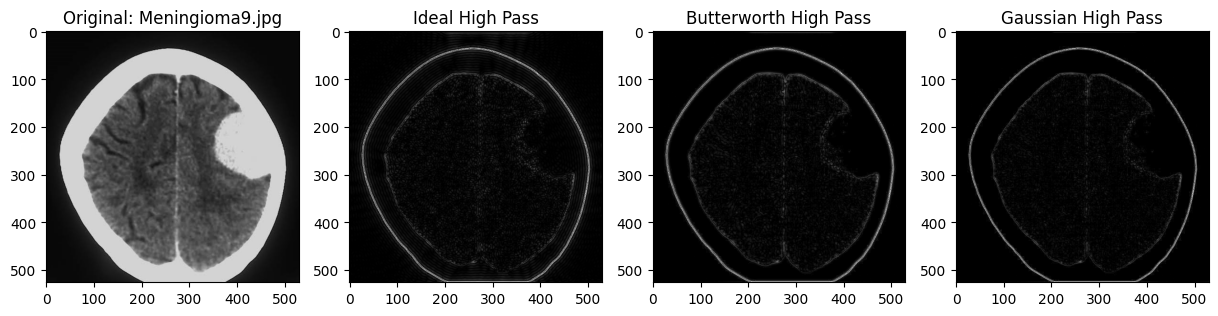

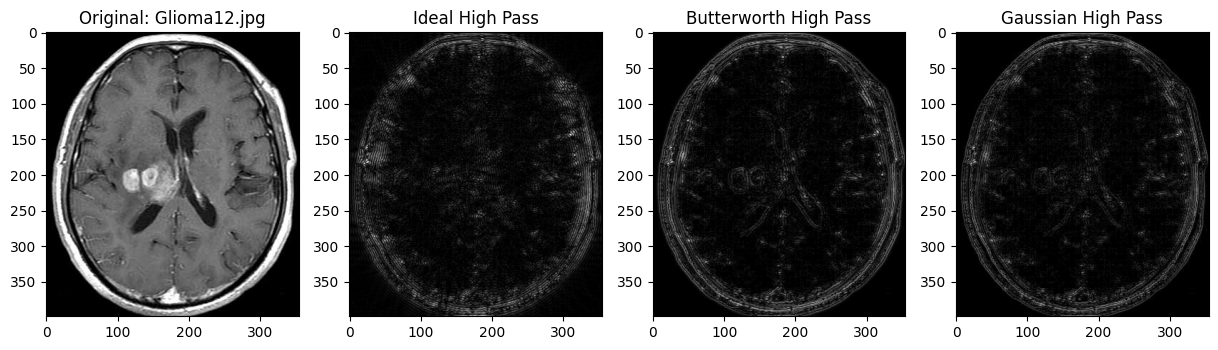

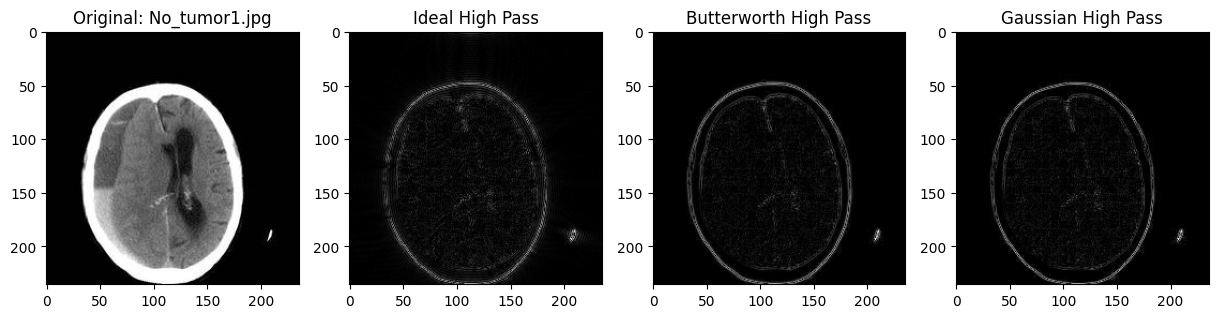

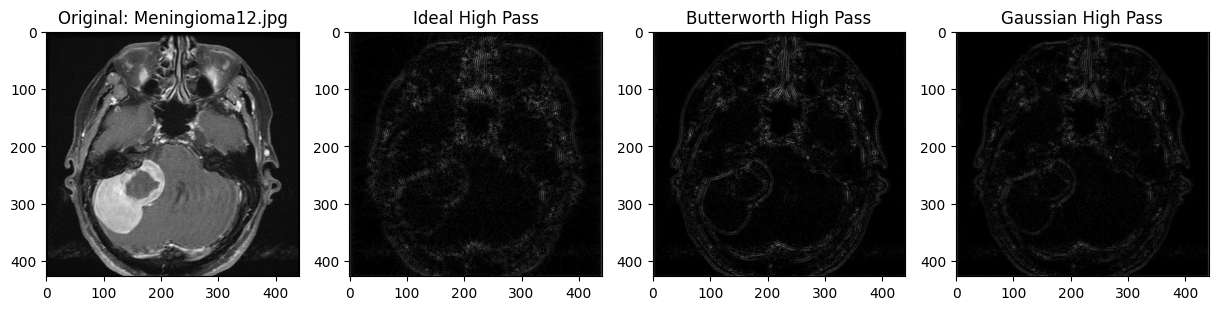

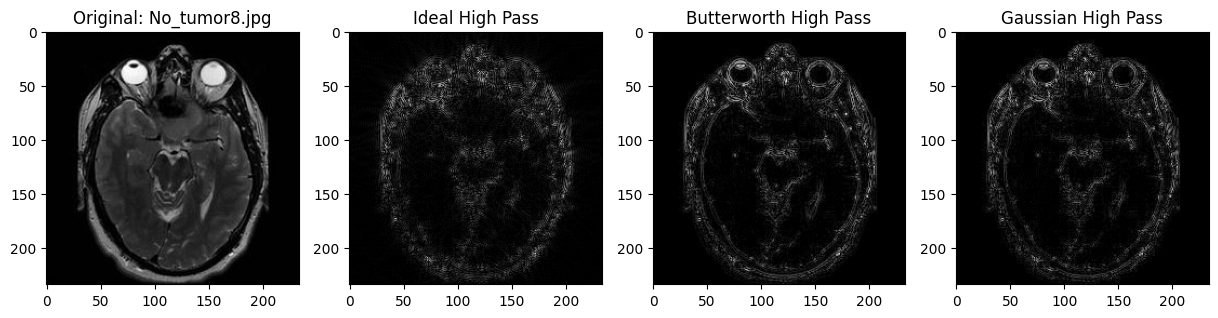

In [ ]:

import cv2
import os
import random
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

def ideal_high_pass_filter(image, cutoff_frequency):
    rows, cols = image.shape[:2]
    center_row, center_col = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
            if distance <= cutoff_frequency:
                mask[i, j] = 0
    return mask

def butterworth_high_pass_filter(image, cutoff_frequency, order):
    rows, cols = image.shape[:2]
    center_row, center_col = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
            mask[i, j] = 1 - (1 / (1 + (distance / cutoff_frequency)**(2 * order)))
    return mask

def gaussian_high_pass_filter(image, cutoff_frequency):
    rows, cols = image.shape[:2]
    center_row, center_col = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
            mask[i, j] = 1 - np.exp(-(distance**2) / (2 * (cutoff_frequency**2)))
    return mask

def process_image_frequency_domain(image, filter_type, cutoff_frequency, order=1):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray_image)
    fshift = np.fft.fftshift(f)

    if filter_type == 'ideal':
        filter_mask = ideal_high_pass_filter(gray_image, cutoff_frequency)
    elif filter_type == 'butterworth':
        filter_mask = butterworth_high_pass_filter(gray_image, cutoff_frequency, order)
    elif filter_type == 'gaussian':
        filter_mask = gaussian_high_pass_filter(gray_image, cutoff_frequency)
    else:
        print('Invalid filter type')
        return image

    filtered_fshift = fshift * filter_mask
    filtered_f = np.fft.ifftshift(filtered_fshift)
    filtered_image = np.fft.ifft2(filtered_f)
    filtered_image = np.abs(filtered_image).astype(np.uint8)
    return filtered_image

# Example usage (replace with your actual paths and parameters)
input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with your input folder
num_images = 5
cutoff_frequency = 50
order = 1

image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]
num_images = min(num_images, len(image_files))
selected_images = random.sample(image_files, num_images)

for image_file in selected_images:
    input_path = os.path.join(input_folder, image_file)
    img = cv2.imread(input_path)
    if img is None:
        print(f"Warning: Could not read image: {input_path}. Skipping")
        continue

    ideal_filtered = process_image_frequency_domain(img, 'ideal', cutoff_frequency)
    butterworth_filtered = process_image_frequency_domain(img, 'butterworth', cutoff_frequency, order)
    gaussian_filtered = process_image_frequency_domain(img, 'gaussian', cutoff_frequency)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original: {image_file}")

    plt.subplot(1, 4, 2)
    plt.imshow(ideal_filtered, cmap='gray')
    plt.title("Ideal High Pass")

    plt.subplot(1, 4, 3)
    plt.imshow(butterworth_filtered, cmap='gray')
    plt.title("Butterworth High Pass")

    plt.subplot(1, 4, 4)
    plt.imshow(gaussian_filtered, cmap='gray')
    plt.title("Gaussian High Pass")

    plt.show()


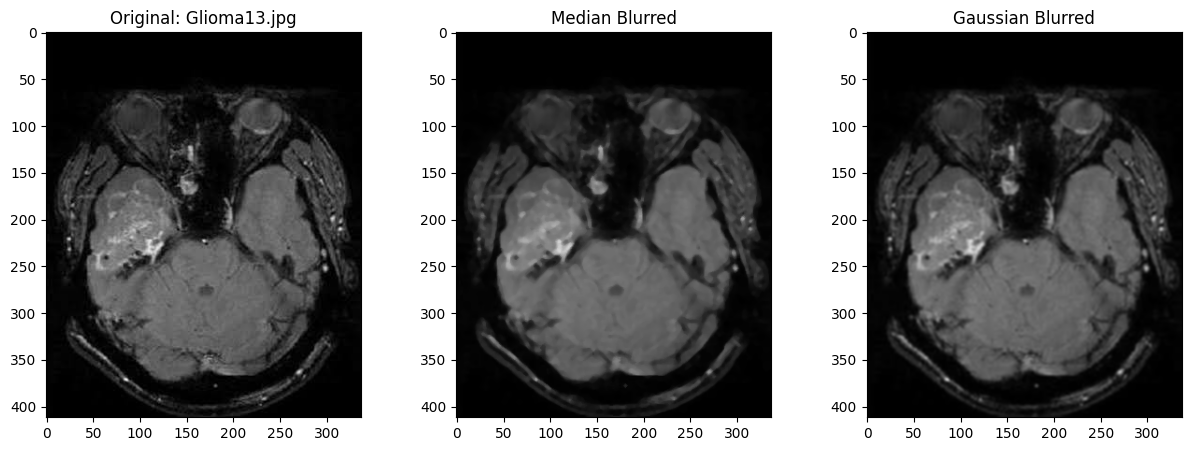

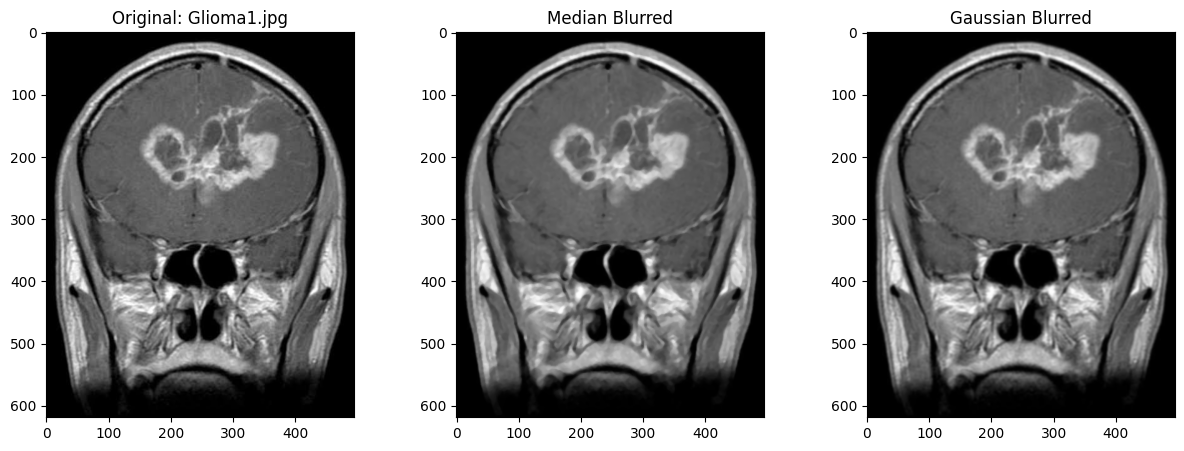

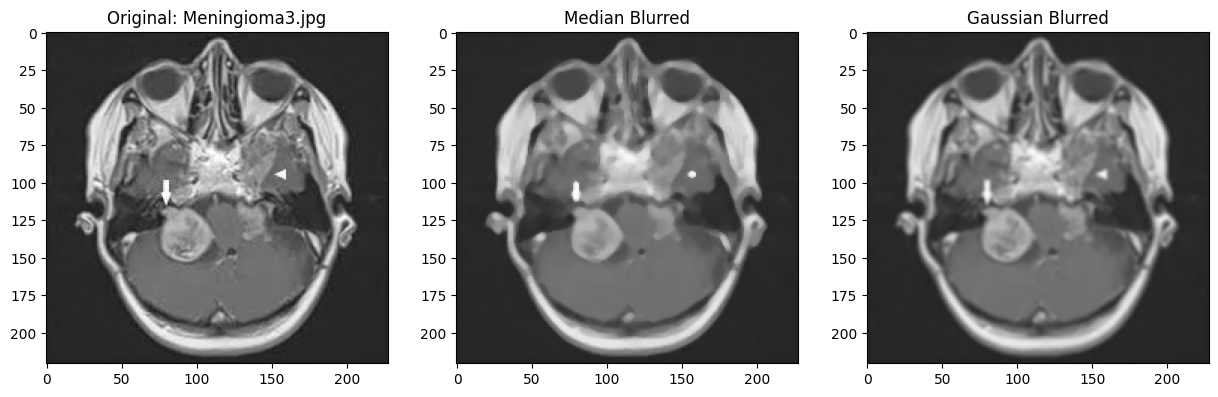

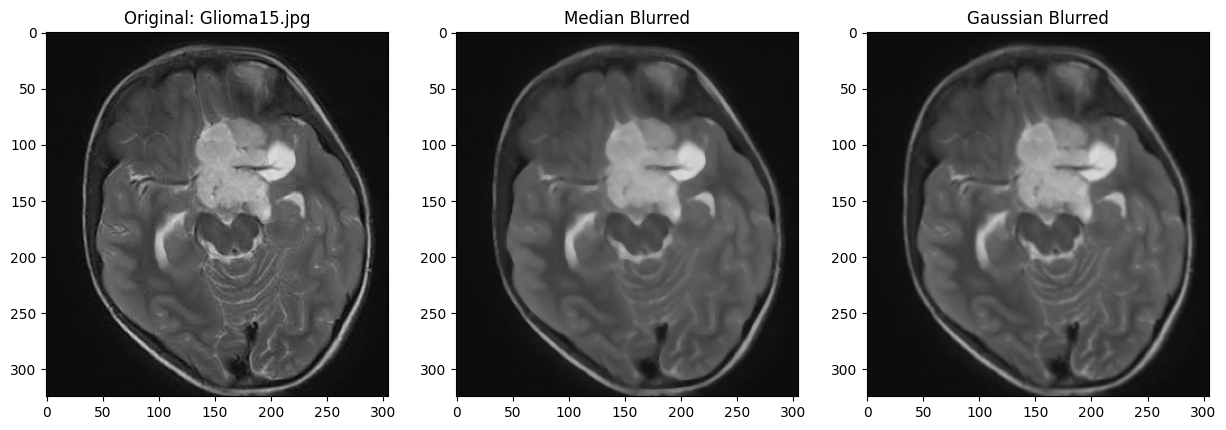

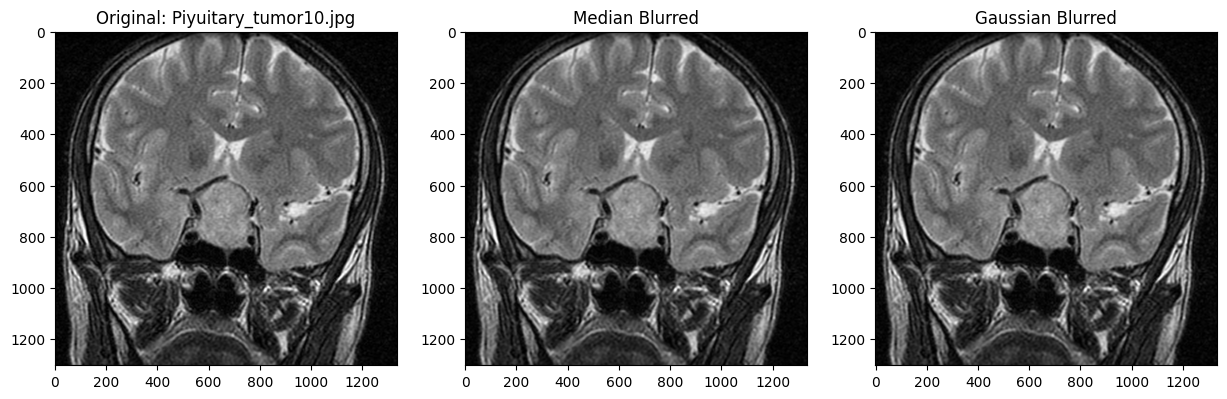

In [ ]:

import cv2
import os
import random
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

def process_images(input_folder, num_images=5):
    image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]
    num_images = min(num_images, len(image_files))
    selected_images = random.sample(image_files, num_images)

    for image_file in selected_images:
        input_path = os.path.join(input_folder, image_file)
        img = cv2.imread(input_path)
        if img is None:
            print(f"Warning: Could not read image: {input_path}. Skipping")
            continue

        # Apply Median Blur
        median_blurred = cv2.medianBlur(img, 5)  # Kernel size 5

        # Apply Gaussian Blur
        gaussian_blurred = cv2.GaussianBlur(img, (5, 5), 0)  # Kernel size 5x5, sigma=0

        # Display the original and processed images
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {image_file}")

        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(median_blurred, cv2.COLOR_BGR2RGB))
        plt.title("Median Blurred")

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(gaussian_blurred, cv2.COLOR_BGR2RGB))
        plt.title("Gaussian Blurred")

        plt.show()

# Example usage
input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with the actual path to your image folder
process_images(input_folder)


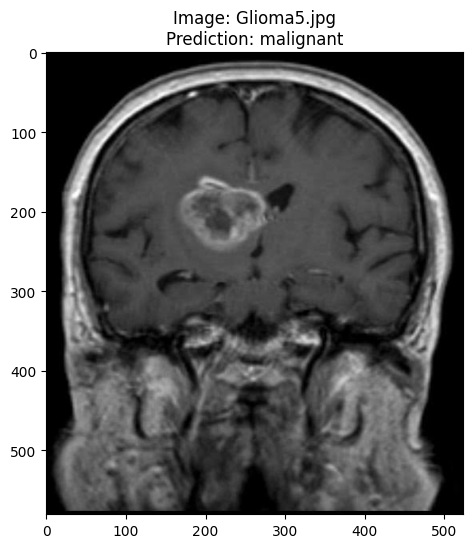

Brain tumor is present and it is malignant


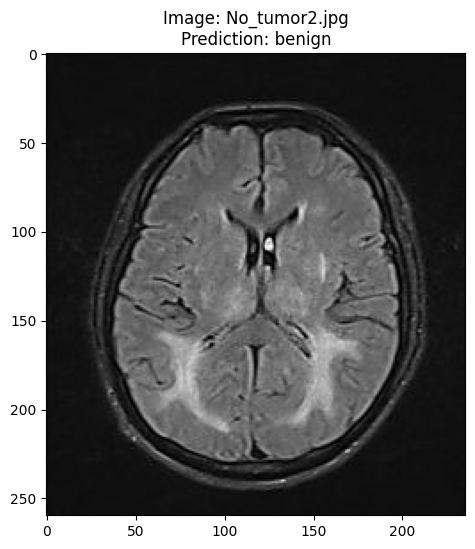

Brain tumor is present and it is benign


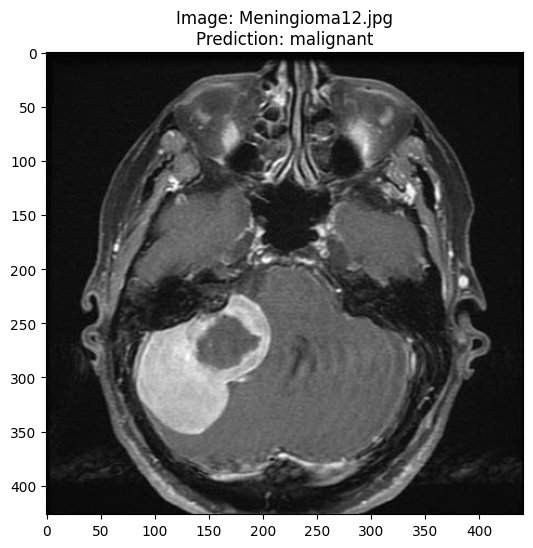

Brain tumor is present and it is malignant


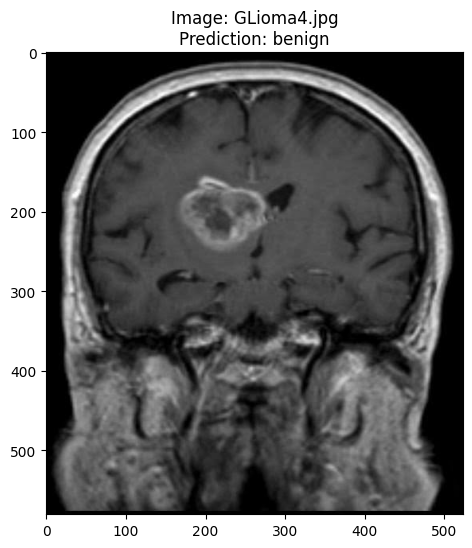

Brain tumor is present and it is benign


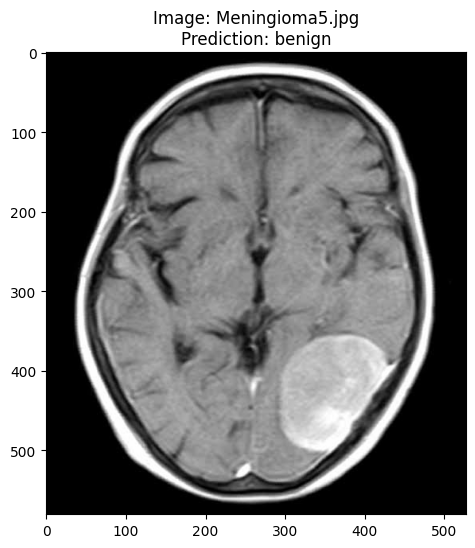

Brain tumor is present and it is benign


In [ ]:

import cv2
import os
import random
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Placeholder for the actual tumor prediction model
# Replace this with your trained model
def predict_tumor(image_path):
    # This is a dummy prediction, replace with your actual model
    random_prediction = random.choice(["benign", "malignant"])
    return random_prediction

# Function to process images and make predictions
def process_images(input_folder, num_images=5):
    image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]
    num_images = min(num_images, len(image_files))
    selected_images = random.sample(image_files, num_images)

    for image_file in selected_images:
        input_path = os.path.join(input_folder, image_file)
        img = cv2.imread(input_path)
        if img is None:
            print(f"Warning: Could not read image: {input_path}. Skipping")
            continue

        # Prediction
        tumor_type = predict_tumor(input_path)

        # Display the image and prediction
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Image: {image_file}\nPrediction: {tumor_type}")
        plt.show()
        print(f"Brain tumor is present and it is {tumor_type}")


# Example usage
input_folder = "/content/drive/MyDrive/Brain Tumors"  # Replace with your input folder
process_images(input_folder)


In [ ]:
import os
print(os.path.exists('/content/brain_tumor_model.h5'))


False


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/drive/MyDrive/Brain Tumor/train'
val_dir = '/content/drive/MyDrive/Brain Tumor/val'
IMG_SIZE = (128, 128)

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary'
)

if train_data.samples == 0 or val_data.samples == 0:
    print("⚠ No images found! Please check folder structure and image files.")

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(train_data, validation_data=val_data, epochs=10)

model.save('/content/brain_tumor_model.h5')

Found 14 images belonging to 3 classes.
Found 16 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4286 - loss: 0.6470 - val_accuracy: 0.4375 - val_loss: -7.3453
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step - accuracy: 0.5000 - loss: -6.6989 - val_accuracy: 0.4375 - val_loss: -17.7219
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: -16.1370 - val_accuracy: 0.4375 - val_loss: -33.1863
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: -30.1788 - val_accuracy: 0.4375 - val_loss: -55.0052
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: -49.9630 - val_accuracy: 0.4375 - val_loss: -84.5566
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step - accuracy: 0.5000 - loss: -76.7307 - val_accuracy: 0.4375 - val_loss: -123.4679
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step - accuracy: 0.5000 - loss: -111.9433 - val_accuracy: 0.4375 - val_loss: -173.7115
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - accuracy: 0.5000 - loss: -157.3713 - val_accuracy: 

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model('/content/brain_tumor_model.h5')
IMG_SIZE = (128, 128)

def predict_tumor(image_path):
    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    return "malignant" if prediction[0][0] > 0.5 else "benign"

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

def process_images(input_folder, num_images=5):
    image_files = [f for f in os.listdir(input_folder) if os.path.isfile(os.path.join(input_folder, f))]
    if not image_files:
        print("⚠ No test images found in folder.")
        return

    selected_images = random.sample(image_files, min(num_images, len(image_files)))

    for image_file in selected_images:
        input_path = os.path.join(input_folder, image_file)
        img = cv2.imread(input_path)

        if img is None:
            print(f"Could not read image: {image_file}")
            continue

        tumor_type = predict_tumor(input_path)

        plt.figure(figsize=(6, 5))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediction: {tumor_type}")
        plt.axis('off')
        plt.show()

        print(f"🧠 Brain tumor detected and it is *{tumor_type}*.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


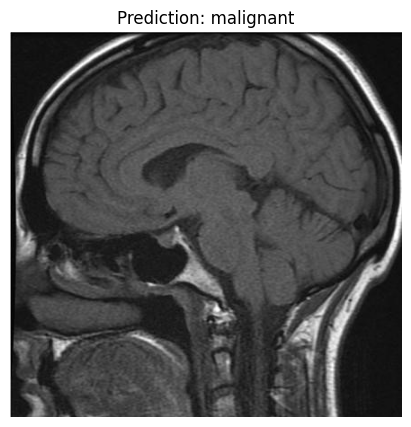

🧠 Brain tumor detected and it is *malignant*.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


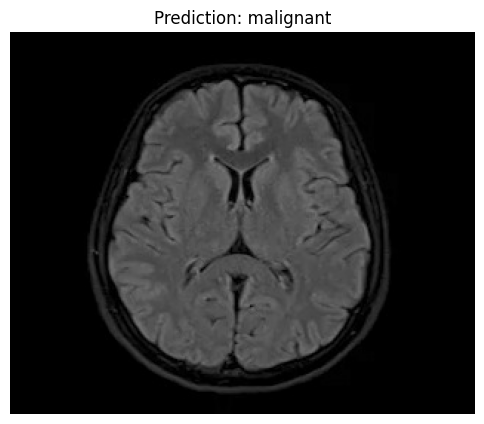

🧠 Brain tumor detected and it is *malignant*.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


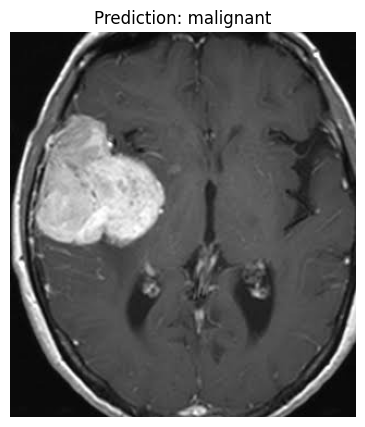

🧠 Brain tumor detected and it is *malignant*.


In [ ]:
input_folder = '/content/drive/MyDrive/Brain Tumor/test'
process_images(input_folder)